# Random Forest leaf policies versus fixed leaf sizes

Task 10101, ten SMAC seeds, 200 trials.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

HERE = Path.cwd()
if HERE.name != "03_leaf_policies_task_10101" or HERE.parent.name != "random_forest":
    HERE = Path("experiments/HPOBench_leafs/random_forest/03_leaf_policies_task_10101").resolve()
fixed_paths = sorted((HERE.parent / "01_initial" / "smac_output").glob("leaf_*/*/trajectory.json"))
policy_paths = sorted((HERE / "smac_output").glob("*/*/trajectory.json"))
if not fixed_paths or not policy_paths:
    raise FileNotFoundError("Run both 01_initial fixed leaf sizes and run_leaf_policies.py first.")
results = []
for path in fixed_paths:
    result = json.loads(path.read_text()); result["series"] = f"fixed leaf {result['min_samples_leaf']}"; result["kind"] = "fixed"; results.append(result)
for path in policy_paths:
    result = json.loads(path.read_text()); result["series"] = result["policy"]; result["kind"] = "policy"; results.append(result)
print(f"Loaded {len(fixed_paths)} fixed and {len(policy_paths)} policy trajectories.")
rows = []
for result in results:
    rows.extend({"series": result["series"], "kind": result["kind"], "seed": result["smac_seed"], "iteration": i, "best_so_far": best} for i, best in zip(result["iteration"], result["best_so_far"]))
trajectories = pd.DataFrame(rows)
SERIES = ["fixed leaf 1", "fixed leaf 2", "fixed leaf 3", "rotate_10", "staged_100_then_1"]
colors = dict(zip(SERIES, plt.cm.tab10(np.arange(len(SERIES)))))

Loaded 30 fixed and 20 policy trajectories.


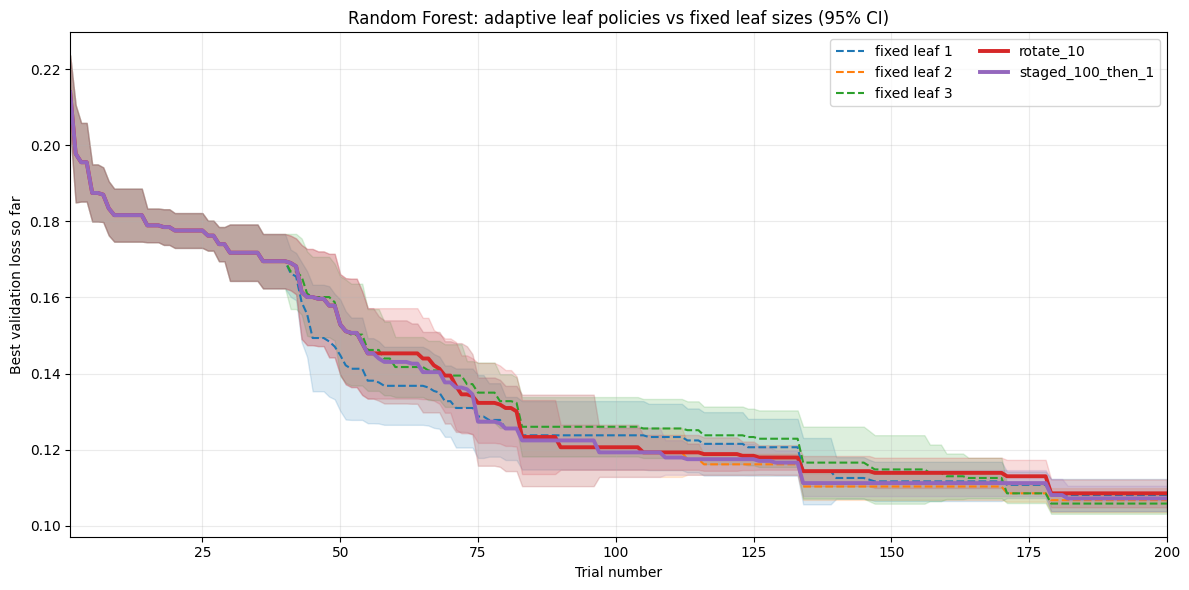

In [2]:
summary = trajectories.groupby(["series", "kind", "iteration"])["best_so_far"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for name in SERIES:
    data = summary[summary["series"] == name]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    is_policy = name in {"rotate_10", "staged_100_then_1"}
    ax.plot(x, mean, color=colors[name], linestyle="-" if is_policy else "--", linewidth=2.8 if is_policy else 1.5, label=name)
    ax.fill_between(x, mean-ci, mean+ci, color=colors[name], alpha=0.16)
ax.set(title="Random Forest: adaptive leaf policies vs fixed leaf sizes (95% CI)", xlabel="Trial number", ylabel="Best validation loss so far", xlim=(1, 200))
ax.grid(alpha=0.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()

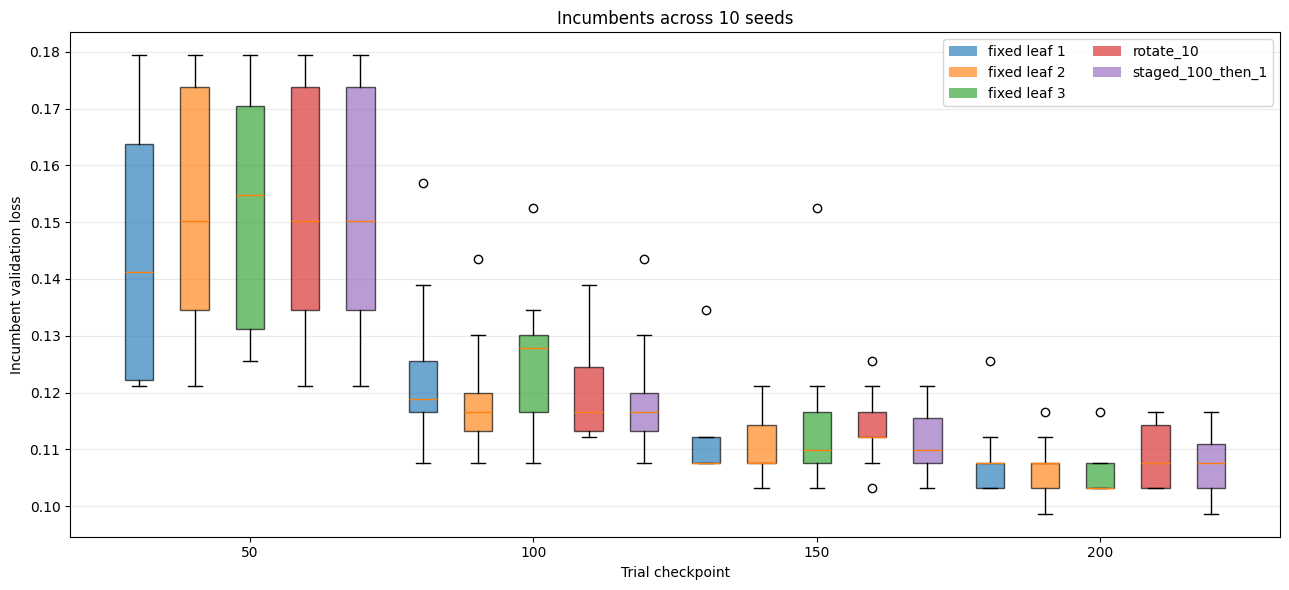

,count,mean,std,min,25%,50%,75%,max
series,,,,,,,,
fixed leaf 1,10.0,0.108072,0.006834,0.103139,0.103139,0.107623,0.107623,0.125561
fixed leaf 2,10.0,0.106726,0.005091,0.098655,0.103139,0.107623,0.107623,0.116592
fixed leaf 3,10.0,0.105830,0.004332,0.103139,0.103139,0.103139,0.107623,0.116592
rotate_10,10.0,0.108520,0.005904,0.103139,0.103139,0.107623,0.114350,0.116592
staged_100_then_1,10.0,0.107175,0.005369,0.098655,0.103139,0.107623,0.110987,0.116592


In [3]:
checkpoints = (50, 100, 150, 200)
base = np.arange(len(checkpoints)); offsets = dict(zip(SERIES, np.linspace(-0.39, 0.39, len(SERIES))))
fig, ax = plt.subplots(figsize=(13, 6))
for name in SERIES:
    values = [trajectories.loc[(trajectories["series"] == name) & (trajectories["iteration"] == cp), "best_so_far"].to_numpy() for cp in checkpoints]
    boxes = ax.boxplot(values, positions=base+offsets[name], widths=0.1, patch_artist=True, manage_ticks=False)
    for box in boxes["boxes"]: box.set(facecolor=colors[name], alpha=0.65)
ax.set(title="Incumbents across 10 seeds", xlabel="Trial checkpoint", ylabel="Incumbent validation loss", xticks=base, xticklabels=checkpoints)
ax.legend(handles=[Patch(facecolor=colors[n], alpha=0.65, label=n) for n in SERIES], ncol=2); ax.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()
trajectories[trajectories["iteration"] == 200].groupby("series")["best_so_far"].describe().loc[SERIES]